In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("imdb_movies_2000to2022.actorXgenre.csv")

In [3]:
print(df.head())

    actor_id  Comedy  Fantasy  Romance  Drama  Mystery  Thriller  Action  \
0  nm0000212     7.0      1.0      6.0    6.0      1.0       2.0     1.0   
1  nm0413168     7.0      3.0      5.0   12.0      5.0       2.0    14.0   
2  nm0000630     8.0      2.0      6.0   14.0      2.0       3.0     4.0   
3  nm0005227    10.0      1.0      2.0    2.0      0.0       1.0     1.0   
4  nm0864851     1.0      0.0      0.0    0.0      0.0       0.0     0.0   

   Biography  Crime  ...  Horror  Documentary  Sport  News  Family  Music  \
0        1.0    2.0  ...     0.0          0.0    0.0   0.0     0.0    0.0   
1        4.0    6.0  ...     0.0          0.0    0.0   0.0     0.0    0.0   
2        5.0    1.0  ...     3.0          7.0    3.0   1.0     0.0    0.0   
3        0.0    0.0  ...     1.0          0.0    1.0   0.0     2.0    0.0   
4        0.0    0.0  ...     1.0          0.0    0.0   0.0     0.0    0.0   

   Unnamed: 22  Western  Short  Reality-TV  
0          0.0      0.0    0.0     

In [4]:
X = df.select_dtypes(include=['number'])
X = X.fillna(0)

In [5]:
# Step 5: Take a sample (for speed if dataset is large)
X_sample = X.sample(n=min(1000, len(X)), random_state=42)

# Step 6: Run K-Means for smaller k range (faster)
inertia_values = []
k_values = range(2, 15)

In [6]:
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5,      # reduced from 10
        max_iter=100   # reduced iterations
    )
    kmeans.fit(X_sample)
    inertia_values.append(kmeans.inertia_)

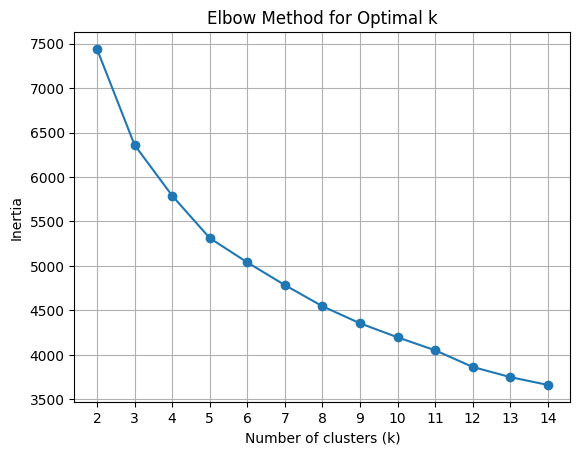

In [7]:
# Step 7: Plot the elbow curve
plt.figure()
plt.plot(k_values, inertia_values, marker='o')
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid()
plt.show()